In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
data = pd.read_csv("Housing.csv")

In [3]:
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [6]:
data.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [7]:
data.shape

(545, 13)

In [8]:
data.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [9]:
data.duplicated().sum()

0

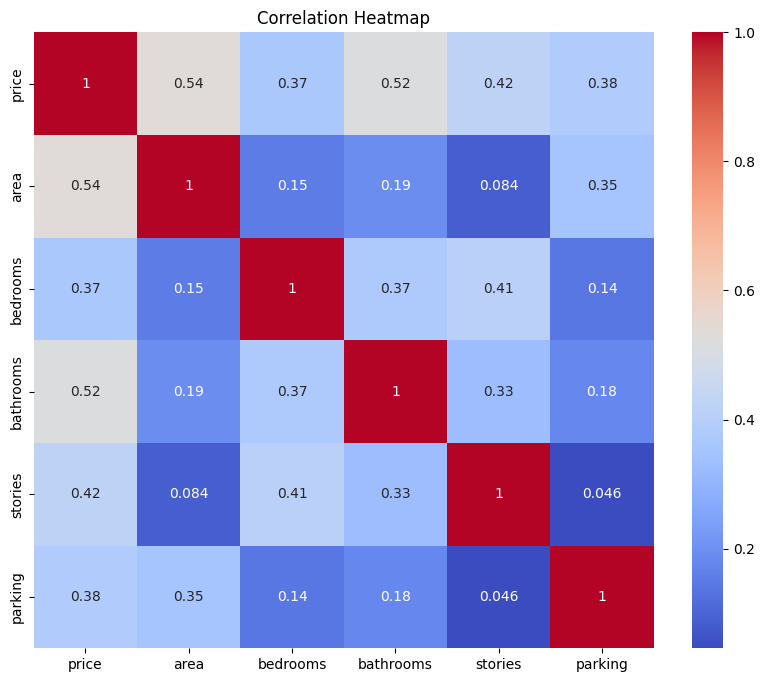

In [10]:
plt.figure(figsize=(10,8))

sns.heatmap(data.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

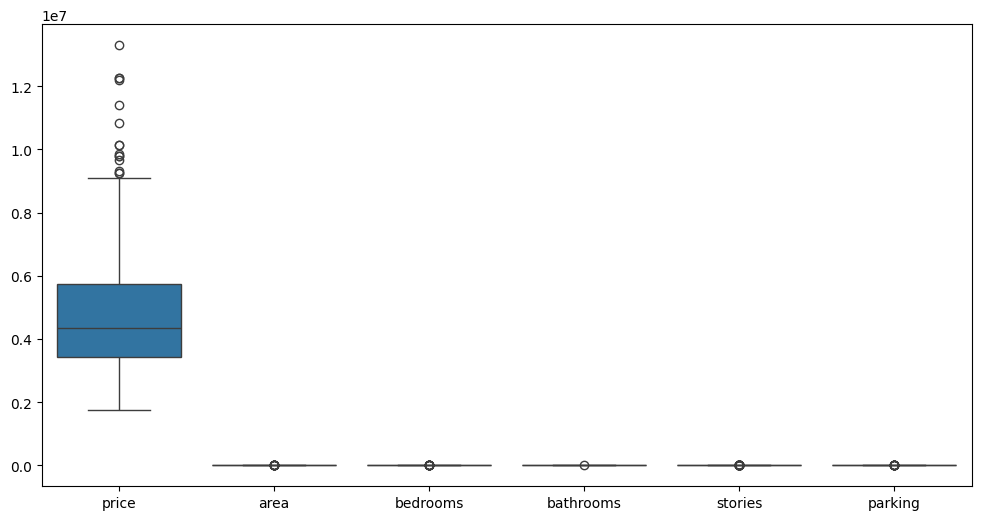

In [11]:
plt.figure(figsize=(12,6))

sns.boxplot(data=data.select_dtypes(include=np.number))

plt.show()

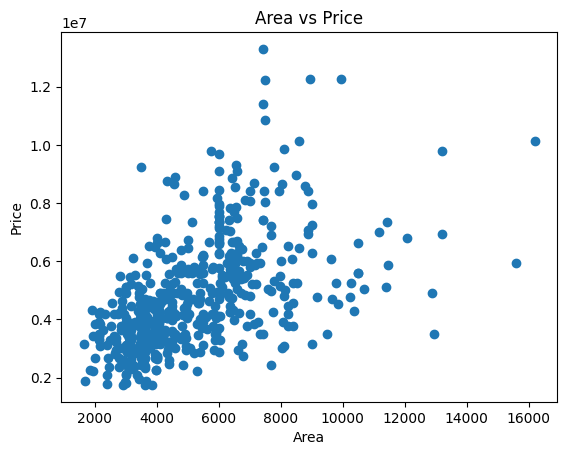

In [12]:
plt.scatter(data['area'], data['price'])

plt.xlabel("Area")

plt.ylabel("Price")

plt.title("Area vs Price")

plt.show()

In [13]:
X = data[['area', 'bedrooms', 'bathrooms']]

y = data['price']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
sc = StandardScaler()

X_train = sc.fit_transform(X_train)

X_test = sc.transform(X_test)

In [16]:
neighbors = range(1, 21)

scores = []

for k in neighbors:

    model = KNeighborsRegressor(n_neighbors=k)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    score = r2_score(y_test, y_pred)

    scores.append(score)

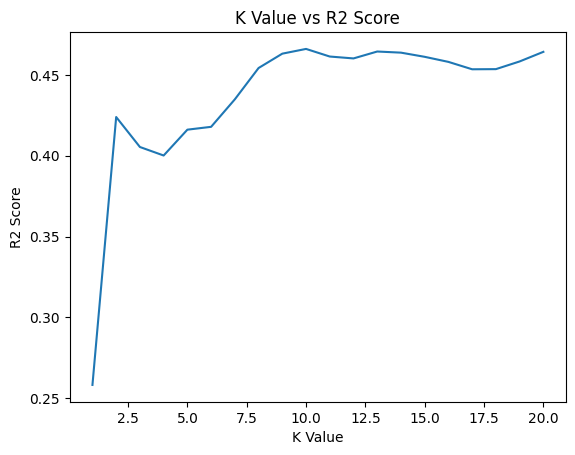

In [17]:
plt.plot(neighbors, scores)

plt.xlabel("K Value")

plt.ylabel("R2 Score")

plt.title("K Value vs R2 Score")

plt.show()

In [18]:
best_k = neighbors[np.argmax(scores)]

print("Best K Value:", best_k)

Best K Value: 10


In [19]:
model = KNeighborsRegressor(n_neighbors=best_k)

model.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=10)

In [20]:
y_pred = model.predict(X_test)

In [21]:
mse = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)

print("R2 Score:", r2)

Mean Squared Error: 2698228975685.6514
R2 Score: 0.46618033894594757


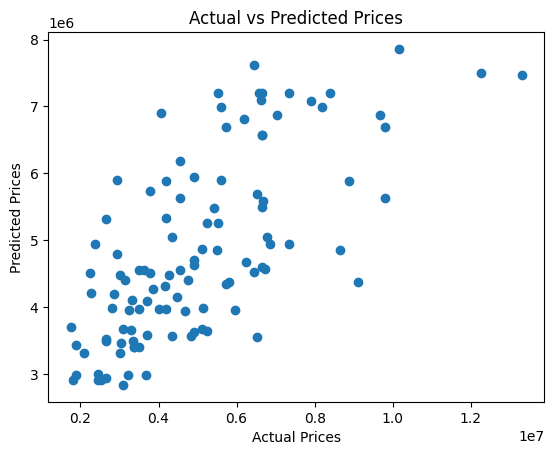

In [22]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")

plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted Prices")

plt.show()